# Kinerja Lengkap Kandidat Strategi — Win Rate, Rugi, Drawdown, Profit

Ringkasan angka untuk memutuskan strategi yang dipakai sistem, setelah riset notebook 06 → 11.
**Tidak ada optimasi baru** di sini — semua parameter sudah ditetapkan sebelumnya:

| Kode | Strategi | Asal |
|---|---|---|
| **A** | Filter tren BTC **SMA50**: pegang BTC 100% saat close > SMA50, else cash | F1, notebook 07/11 |
| **B** | Filter tren BTC **SMA100** (nilai tengah plateau) | F1, notebook 11 |
| **C** | A + **ukuran posisi** min(100%, 2% ÷ volatilitas harian 20 hari) + **circuit breaker 15%** (jeda 30 hari) | alat risiko dari 07/08, **dikonfirmasi sekali** di data segar |
| D | Rotasi momentum 40 coin (Konservatif 07) — **sudah ditolak**, pembanding | notebook 10/11 |
| E | Buy & hold BTC | pembanding |

Periode: **segar 2018-03 → 2020-12** (belum pernah dipakai riset), latih 2021–2023, uji 2024-01 → 2026-06.
D tidak bisa diuji di periode segar (coin lain baru punya data sejak 2021).
Biaya 0.15%/sisi, sinyal di close → eksekusi open besok.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from data_source.loader import load_symbol, discover_symbols
from src.databases import get_connection
from src.services.recommendation.service import MIN_VOLATILITY
from research.single_position import Panel, run, f1_target, f2_target, BTC

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
PERIODS = {"segar 2018-20": ("2018-03-01", "2020-12-31"), "latih 2021-23": ("2021-01-01", "2023-12-31"),
           "uji 2024-26": ("2024-01-01", "2026-06-30"), "penuh 2021-26": ("2021-01-01", "2026-06-30")}

with get_connection() as conn:
    lm = [r[0] for r in conn.execute(
        "SELECT value_param FROM flex_params WHERE type_param='SIMBOL_CRYPTO' AND deleted_at IS NULL "
        "AND description IN ('Large','Mid')").fetchall()]
raw = {s: load_symbol(s, "1d", "full") for s in lm if s in set(discover_symbols("1d", "full"))}
P_all = Panel(raw, "2018-01-01", "2026-06-30")
UNIV = sorted(s for s in raw if P_all.atr_pct[s].median() >= MIN_VOLATILITY and s not in ("PAXGUSDT", "XAUTUSDT", "WBETHUSDT"))
P = Panel({s: raw[s] for s in UNIV}, "2018-01-01", "2026-06-30")
size2 = (0.02 / P.vol(20)).clip(upper=1)

STRATS = {
    "A. Tren BTC SMA50": lambda a, b: run(P, f1_target(P, 50), a, b),
    "B. Tren BTC SMA100": lambda a, b: run(P, f1_target(P, 100), a, b),
    "C. SMA50 + sizing + circuit": lambda a, b: run(P, f1_target(P, 50), a, b, size=size2, circuit_dd=0.15),
    "D. Rotasi 40 coin (ditolak)": lambda a, b: run(P, f2_target(P, 50, 14, 1), a, b, size=size2, circuit_dd=0.15),
    "E. Buy & hold BTC": lambda a, b: run(P, pd.Series(BTC, index=P.dates), a, b),
}
print(f"Universe D: {len(UNIV)} coin")

Universe D: 40 coin


In [2]:
def full_stats(tr: pd.DataFrame, eq: pd.Series) -> dict:
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    total = eq.iloc[-1] / eq.iloc[0] - 1
    dd = eq / eq.cummax() - 1
    under = (dd < 0).astype(int)
    longest_dd = under.groupby((under == 0).cumsum()).sum().max()
    dr = eq.pct_change().dropna()
    monthly = eq.resample("ME").last().pct_change().dropna()
    r = tr["ret"] if len(tr) else pd.Series(dtype=float)
    wins, losses = r[r > 0], r[r <= 0]
    return {
        "profit_total": total,
        "profit_per_tahun (CAGR)": (1 + total) ** (1 / years) - 1,
        "max_drawdown": dd.min(),
        "drawdown_terlama_hari": int(longest_dd),
        "sharpe": dr.mean() / dr.std() * np.sqrt(365) if dr.std() > 0 else np.nan,
        "jumlah_trade": len(r),
        "win_rate": (r > 0).mean() if len(r) else np.nan,
        "rata2_untung_per_trade": wins.mean() if len(wins) else np.nan,
        "rata2_rugi_per_trade": losses.mean() if len(losses) else np.nan,
        "untung_terbesar": r.max() if len(r) else np.nan,
        "rugi_terbesar": r.min() if len(r) else np.nan,
        "profit_factor": wins.sum() / -losses.sum() if len(losses) and losses.sum() < 0 else np.nan,
        "rata2_hari_pegang": tr["days"].mean() if len(tr) else np.nan,
        "bulan_terburuk": monthly.min(),
        "persen_bulan_untung": (monthly > 0).mean(),
        "waktu_di_pasar": eq.attrs.get("exposure", np.nan),
    }

PCT = ["profit_total", "profit_per_tahun (CAGR)", "max_drawdown", "win_rate", "rata2_untung_per_trade",
       "rata2_rugi_per_trade", "untung_terbesar", "rugi_terbesar", "bulan_terburuk", "persen_bulan_untung", "waktu_di_pasar"]

def fmt_table(d: dict) -> pd.DataFrame:
    df = pd.DataFrame(d)
    out = df.copy().astype(object)
    for idx in df.index:
        for col in df.columns:
            v = df.at[idx, col]
            if pd.isna(v):
                out.at[idx, col] = "-"
            elif idx in PCT:
                out.at[idx, col] = f"{v:+.1%}"
            elif idx in ("sharpe", "profit_factor", "rata2_hari_pegang"):
                out.at[idx, col] = f"{v:.2f}"
            else:
                out.at[idx, col] = f"{int(v)}"
    return out

results, equities = {}, {}
for per_name, (a, b) in PERIODS.items():
    results[per_name] = {}
    for name, fn in STRATS.items():
        if name.startswith("D.") and per_name.startswith("segar"):
            continue
        tr, eq = fn(a, b)
        results[per_name][name] = full_stats(tr, eq)
        equities[(per_name, name)] = eq

## 1. Periode uji 2024-01 → 2026-06 (out-of-sample)

In [3]:
fmt_table(results["uji 2024-26"])

,A. Tren BTC SMA50,B. Tren BTC SMA100,C. SMA50 + sizing + circuit,D. Rotasi 40 coin (ditolak),E. Buy & hold BTC
profit_total,+64.8%,+49.1%,+53.8%,+28.8%,+32.3%
profit_per_tahun (CAGR),+22.2%,+17.4%,+18.8%,+10.7%,+11.9%
max_drawdown,-26.7%,-36.6%,-25.8%,-38.3%,-53.0%
drawdown_terlama_hari,321,321,321,344,267
sharpe,0.77,0.64,0.76,0.47,0.47
jumlah_trade,30,21,29,165,1
win_rate,+23.3%,+14.3%,+20.7%,+40.6%,+100.0%
rata2_untung_per_trade,+18.9%,+34.0%,+19.7%,+10.1%,+32.3%
rata2_rugi_per_trade,-2.6%,-2.5%,-2.7%,-4.8%,-
untung_terbesar,+50.3%,+52.7%,+50.3%,+122.9%,+32.3%


## 2. Periode segar 2018-03 → 2020-12 (belum pernah dipakai riset mana pun)

In [4]:
fmt_table(results["segar 2018-20"])

,A. Tren BTC SMA50,B. Tren BTC SMA100,C. SMA50 + sizing + circuit,E. Buy & hold BTC
profit_total,+334.9%,+345.4%,+480.1%,+164.0%
profit_per_tahun (CAGR),+67.9%,+69.3%,+85.9%,+40.8%
max_drawdown,-50.9%,-34.9%,-28.2%,-72.1%
drawdown_terlama_hari,434,497,429,485
sharpe,1.32,1.35,1.90,0.85
jumlah_trade,29,18,27,1
win_rate,+20.7%,+16.7%,+22.2%,+100.0%
rata2_untung_per_trade,+63.8%,+112.9%,+67.1%,+164.0%
rata2_rugi_per_trade,-4.2%,-3.7%,-3.8%,-
untung_terbesar,+163.9%,+170.3%,+175.7%,+164.0%


## 3. Periode latih 2021 → 2023

In [5]:
fmt_table(results["latih 2021-23"])

,A. Tren BTC SMA50,B. Tren BTC SMA100,C. SMA50 + sizing + circuit,D. Rotasi 40 coin (ditolak),E. Buy & hold BTC
profit_total,+160.3%,+148.3%,+43.0%,+340.5%,+43.7%
profit_per_tahun (CAGR),+37.6%,+35.5%,+12.7%,+64.1%,+12.9%
max_drawdown,-58.5%,-38.7%,-49.7%,-30.6%,-76.6%
drawdown_terlama_hari,756,518,799,321,783
sharpe,0.94,0.89,0.57,1.54,0.51
jumlah_trade,27,18,25,173,1
win_rate,+25.9%,+38.9%,+28.0%,+43.9%,+100.0%
rata2_untung_per_trade,+34.6%,+26.6%,+19.8%,+12.4%,+43.7%
rata2_rugi_per_trade,-4.8%,-5.6%,-5.4%,-5.4%,-
untung_terbesar,+90.9%,+66.8%,+56.0%,+111.8%,+43.7%


## 4. Penuh 2021-01 → 2026-06

In [6]:
fmt_table(results["penuh 2021-26"])

,A. Tren BTC SMA50,B. Tren BTC SMA100,C. SMA50 + sizing + circuit,D. Rotasi 40 coin (ditolak),E. Buy & hold BTC
profit_total,+349.6%,+287.9%,+129.9%,+469.1%,+99.3%
profit_per_tahun (CAGR),+31.5%,+28.0%,+16.4%,+37.2%,+13.4%
max_drawdown,-58.5%,-38.7%,-49.7%,-38.3%,-76.6%
drawdown_terlama_hari,756,518,799,344,846
sharpe,0.89,0.81,0.68,1.07,0.51
jumlah_trade,56,38,53,338,1
win_rate,+25.0%,+23.7%,+24.5%,+42.3%,+100.0%
rata2_untung_per_trade,+26.6%,+34.8%,+19.6%,+11.3%,+99.3%
rata2_rugi_per_trade,-3.6%,-3.7%,-3.9%,-5.1%,-
untung_terbesar,+90.9%,+104.2%,+54.0%,+122.9%,+99.3%


## 5. Return per tahun

In [7]:
yr = {}
for name, fn in STRATS.items():
    if name.startswith("D."):
        _, eq = fn("2021-01-01", "2026-06-30")
    else:
        _, eq = fn("2018-03-01", "2026-06-30")
    yr[name] = eq.groupby(eq.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
per_year = pd.DataFrame(yr).T
per_year.columns = [f"{y}{' (s/d Jun)' if y == 2026 else (' (Mar-Des)' if y == 2018 else '')}" for y in per_year.columns]
per_year.map(lambda v: f"{v:+.0%}" if pd.notna(v) else "-")

,2018 (Mar-Des),2019,2020,2021,2022,2023,2024,2025,2026 (s/d Jun)
A. Tren BTC SMA50,-41%,+80%,+311%,+122%,-51%,+138%,+68%,+3%,-5%
B. Tren BTC SMA100,-28%,+133%,+166%,+74%,-21%,+81%,+56%,+3%,-8%
C. SMA50 + sizing + circuit,-22%,+111%,+252%,+17%,-34%,+122%,+76%,-0%,-13%
D. Rotasi 40 coin (ditolak),-,-,-,+187%,-1%,+55%,+72%,-7%,-19%
E. Buy & hold BTC,-66%,+89%,+302%,+58%,-65%,+154%,+112%,-7%,-34%


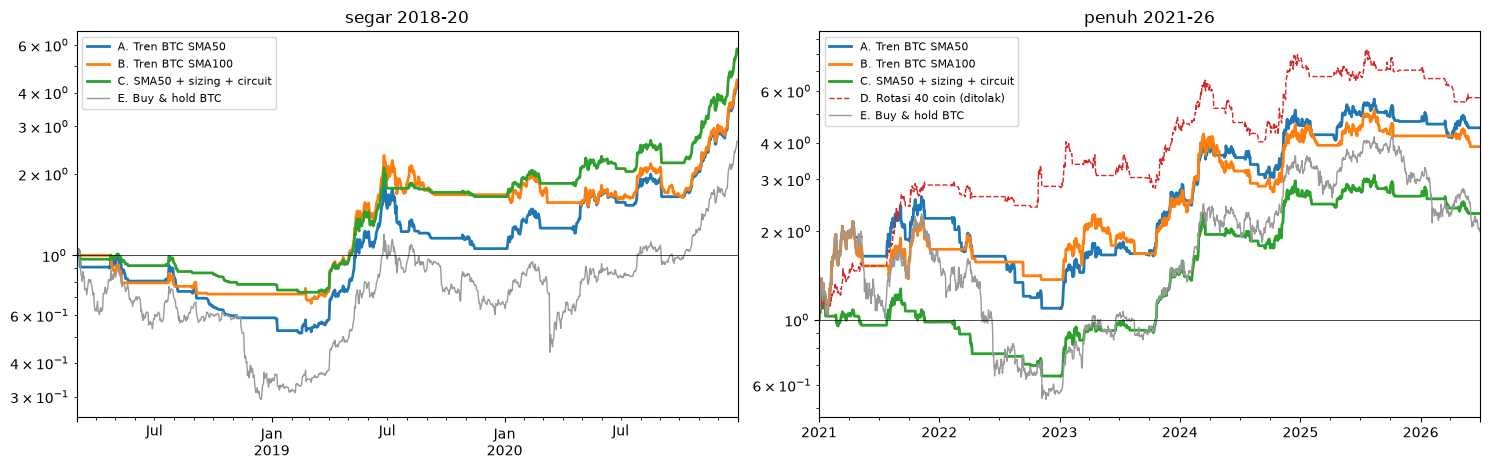

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, per in zip(axes, ("segar 2018-20", "penuh 2021-26")):
    for name in STRATS:
        if (per, name) in equities:
            e = equities[(per, name)]
            e.plot(ax=ax, lw=1 if name.startswith(("D.", "E.")) else 2, label=name,
                   color="#999999" if name.startswith("E.") else None, ls="--" if name.startswith("D.") else "-")
    ax.set_yscale("log"); ax.axhline(1, color="black", lw=0.5); ax.set_title(per); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Kesimpulan

### Ciri utama strategi filter tren (A, B, C): **win rate rendah, untung besar, rugi kecil**
- Win rate hanya **~15–40%** → **sebagian besar trade rugi**, tapi ruginya kecil
  (rata-rata −2.5% s/d −5.6%, terburuk −10% s/d −15%) dan untungnya besar (rata-rata +19% s/d +113%).
- Profit factor **1.4–6.1** (total untung ÷ total rugi) → tetap untung walau sering kalah.
- Rata-rata memegang posisi **15–30 hari**, ~10 trade per tahun, di pasar hanya ~50% waktu.
- **Drawdown bisa lama**: 321–799 hari di bawah puncak equity. Butuh bot yang disiplin — tepat
  alasan sistem ini dibuat otonom.

### Perbandingan kandidat (max drawdown)
| Periode | A. SMA50 | **B. SMA100** | C. SMA50 + sizing + circuit | E. Buy & hold BTC |
|---|---|---|---|---|
| Segar 2018–20 | −50.9% | **−34.9%** | −28.2% | −72.1% |
| Latih 2021–23 | −58.5% | **−38.7%** | −49.7% | −76.6% |
| Uji 2024–26 | −26.7% | **−36.6%** | −25.8% | −53.0% |
| Tahun terburuk | 2022: −51% | **2018: −28%** | 2022: −34% | 2018: −66% |

- **B (SMA100) paling konsisten**: drawdown selalu di kisaran −35% s/d −39% di ketiga periode,
  tahun terburuk −28% (BTC −66%), trade paling sedikit (biaya rendah). Return uji lebih rendah dari A
  (+49% vs +65%), tapi tetap di atas BTC (+32%).
- **A (SMA50)** return lebih tinggi di beberapa periode, tapi drawdown bisa −51% s/d −59% (2022).
- **C (sizing + circuit)** sangat bagus di data segar 2018–20 (Sharpe 1.90, DD −28%) tapi buruk di
  2021–23 (+43% vs +160%): ukuran posisi mengecil saat bull 2021 yang volatil. **Tidak konsisten** —
  sesuai janji "uji sekali lalu berhenti", C tidak dipakai sebagai aturan utama.
- **D (rotasi 40 coin)** di periode latih terlihat terbaik (+340%, Sharpe 1.54) tapi di uji setara BTC —
  contoh klasik overfitting, dan rugi per trade terbesar (−24%).

### Rekomendasi aturan utama: **B — filter tren BTC SMA100**
1. Setiap hari setelah candle harian close: kalau **close BTC > SMA100 BTC → pegang BTC**, kalau tidak → **cash**.
2. Eksekusi di open hari berikutnya.
3. Ekspektasi realistis (dari 3 periode): profit ±17–69%/tahun (sangat bergantung kondisi pasar),
   **drawdown maksimum ±35–40%**, win rate ±15–40%, rugi per trade biasanya −3% s/d −10%.
4. Catatan jujur: B dipilih setelah melihat ketiga periode (walau SMA100 sudah disebut sebagai
   "nilai tengah plateau" di notebook 11). Validasi terakhirnya harus **paper trading ke depan**.